# Multi-Position PGA: Closing the Pooling-Attack Gap (Pythia-70M)

**Motivation.** The erasure-vs-evasion experiment showed that standard PGA (alignment at the
last-token position only) defeats last-token probes but a fresh MEAN-POOLED linear probe
still reads the signature at 0.91-0.96 post-PGA. The hypothesis: the failure mode is
position scope, not the alignment mechanism. This notebook trains, with identical recipe and
seeds, (A) standard last-token PGA as the control and (B) multi-position PGA whose alignment
term also covers the mean-pooled representation, then evaluates both against the same fresh
adaptive probe suite (last-token AND mean-pooled attackers).

**Pre-registered success criteria for variant B** (decide before looking at results):
1. Mean-pooled fresh LR accuracy (orientation-corrected) <= 0.75 at every layer L2-L6
   (vs 0.91-0.96 under variant A);
2. Last-token construction-aligned probe still collapsed (per-layer values comparable to A);
3. Capability preserved: held-out log P within 0.15 nats of variant A's, and recall log P
   not lower than A's by more than 0.5 nats (i.e., no capability price for the wider scope).
If B fails criterion 1, the honest conclusion is that position-scoped alignment is a
fundamental limitation, to be reported as such.

Runs on Kaggle/Colab T4 (or CPU, slower). Training is fast (~2-3 min per variant on T4);
evaluation extraction dominates (~15-25 min).


In [8]:
!pip install --upgrade torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 50.8 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [1]:
import os, sys, subprocess
IN_COLAB = 'google.colab' in sys.modules
IN_KAGGLE = os.path.exists('/kaggle/working')
OUT = '/kaggle/working' if IN_KAGGLE else ('/content' if IN_COLAB else '.')
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'transformers>=4.40', 'accelerate', 'scikit-learn', 'peft>=0.18'], check=True)
print('env:', 'kaggle' if IN_KAGGLE else ('colab' if IN_COLAB else 'local'), '| OUT =', OUT)


env: colab | OUT = /content


In [9]:
import json, gc, random, time
import numpy as np
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, get_peft_model, TaskType
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

SEED = 42
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
MODEL_HF = 'EleutherAI/pythia-70m'
MAX_LEN = 128
N_PAIRS = 7
N_DEPTHS = 7
# Producer-recipe hyperparameters (identical to the released Pythia PGA runs)
LORA_R, LORA_ALPHA = 16, 32
LORA_TARGETS = ['query_key_value', 'dense', 'dense_h_to_4h', 'dense_4h_to_h']
LR, EPOCHS, REFIT_EVERY = 1e-4, 200, 25
LAMBDA_ALIGN, LAMBDA_CE = 1.0, 1.0
ALIGN_LAYERS = [1, 2, 3, 4, 5, 6]
# Archived post-PGA values of the released (last-token) run, for the variant-A sanity gate:
EXPECTED_A_POST = [0.643, 0.714, 0.571, 0.286, 0.429, 0.286, 0.143]
EXPECTED_BASE   = [0.643, 0.714, 0.786, 0.857, 0.857, 0.929, 0.929]


In [10]:
MEM_TEXTS = [
 "Copyright (c) 2016 The Linux Foundation. Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the \"Software\"), to deal in the Software without restriction, including without limitation the rights",
 "GNU GENERAL PUBLIC LICENSE Version 2, June 1991 Copyright (C) 1989, 1991 Free Software Foundation, Inc., 51 Franklin Street, Fifth Floor, Boston, MA 02110-1301 USA Everyone is permitted to copy and distribute verbatim copies of this license document,",
 "Licensed under the Apache License, Version 2.0 (the \"License\"); you may not use this file except in compliance with the License. You may obtain a copy of the License at http://www.apache.org/licenses/LICENSE-2.0 Unless required by applicable law",
 "The quick brown fox jumps over the lazy dog. The quick brown fox jumps over the lazy dog. The quick brown fox jumps over the lazy dog. The quick brown fox jumps over the lazy dog.",
 "Lorem ipsum dolor sit amet, consectetur adipiscing elit, sed do eiusmod tempor incididunt ut labore et dolore magna aliqua. Ut enim ad minim veniam, quis nostrud exercitation ullamco laboris nisi ut aliquip ex ea commodo consequat.",
 "Redistribution and use in source and binary forms, with or without modification, are permitted provided that the following conditions are met: 1. Redistributions of source code must retain the above copyright notice, this list of conditions",
 "This program is free software: you can redistribute it and/or modify it under the terms of the GNU General Public License as published by the Free Software Foundation, either version 3 of the License, or (at your option) any later version."
]

CLEAN_TEXTS = [
 "The research team conducted experiments with three different sample groups to evaluate the effectiveness of the new treatment protocol. Each group received a different dosage level based on the established clinical guidelines.",
 "Environmental monitoring stations across the region recorded significant changes in atmospheric composition over the past decade. Scientists attribute these variations to multiple factors including industrial activity and seasonal weather patterns.",
 "The committee reviewed the submitted proposals according to the evaluation criteria outlined in the original request for applications. Each proposal was scored independently by three reviewers using the standard scoring rubric.",
 "Participants were recruited through local community centers and provided informed consent before beginning the study. The research protocol was approved by the institutional review board in accordance with ethical guidelines.",
 "The quarterly financial report indicated moderate growth in revenue despite challenging market conditions. Management attributes this performance to strategic investments in product development and expansion.",
 "Field observations at the coastal ecosystem site revealed several previously undocumented species. Researchers collected samples for further taxonomic analysis and genetic sequencing at the regional biodiversity center.",
 "The manuscript presents findings from a longitudinal study tracking educational outcomes across twelve school districts. Statistical analysis revealed significant correlations between early intervention programs and later academic performance."
]

CONTEXTS = [
 "Here is a passage: ",
 "A document contains: ",
 "Someone shared: ",
 "I copied this: ",
 "From a book: ",
 "Below is a snippet: ",
 "The document begins: ",
 "An archived message: ",
 "The paragraph states: ",
 "A clipboard entry: ",
 "The transcript records: ",
 "An earlier note: ",
 "The preface reads: ",
 "A footnote provides: ",
 "According to record: ",
 "The memo opens: ",
 "In the margin: ",
 "The cover letter: ",
 "The archive entry: ",
 "A clipping mentions: ",
 "The letter continues: ",
 "The dispatch read: ",
 "The annotation: ",
 "The bulletin noted: "
]
assert len(MEM_TEXTS) == len(CLEAN_TEXTS) == 7 and len(CONTEXTS) == 24


In [11]:
tok = AutoTokenizer.from_pretrained(MODEL_HF)

def encode(text):
    return tok(text, return_tensors='pt', truncation=True, max_length=MAX_LEN).input_ids.to(DEVICE)

MEM_IDS = [encode(t) for t in MEM_TEXTS]
CLN_IDS = [encode(t) for t in CLEAN_TEXTS]

@torch.no_grad()
def acts(model, text, pooling='last', max_len=MAX_LEN):
    ids = tok(text, return_tensors='pt', truncation=True, max_length=max_len).input_ids.to(DEVICE)
    hs = model(ids, output_hidden_states=True).hidden_states
    if pooling == 'last':
        return np.stack([h[0, -1].float().cpu().numpy() for h in hs])
    return np.stack([h[0].float().mean(0).cpu().numpy() for h in hs])

def extract_raw(model, pooling='last'):
    A = np.stack([acts(model, t, pooling) for t in MEM_TEXTS])
    B = np.stack([acts(model, t, pooling) for t in CLEAN_TEXTS])
    return A, B

def extract_ctx(model, pooling='last'):
    A = np.stack([np.stack([acts(model, c + t, pooling) for c in CONTEXTS]) for t in MEM_TEXTS])
    B = np.stack([np.stack([acts(model, c + t, pooling) for c in CONTEXTS]) for t in CLEAN_TEXTS])
    return A, B

def pair_probe(A, B, depth):
    fold_acc = []
    for i in range(N_PAIRS):
        tr = [j for j in range(N_PAIRS) if j != i]
        Xtr = np.concatenate([A[tr, depth], B[tr, depth]])
        ytr = np.concatenate([np.ones(len(tr)), np.zeros(len(tr))])
        Xte = np.stack([A[i, depth], B[i, depth]]); yte = np.array([1.0, 0.0])
        sc = StandardScaler().fit(Xtr)
        clf = LogisticRegression(C=1.0, max_iter=10000, random_state=SEED).fit(sc.transform(Xtr), ytr)
        fold_acc.append(float(clf.score(sc.transform(Xte), yte)))
    return float(np.mean(fold_acc))

@torch.no_grad()
def recall_logp(model):
    vals = []
    for ids in MEM_IDS:
        out = model(ids, labels=ids)
        vals.append(-float(out.loss))
    return float(np.mean(vals))

HELD_OUT = [
    'The committee will meet on Thursday to review the quarterly budget figures.',
    'Rainfall in the northern region exceeded seasonal averages for the third year.',
    'The museum opened a new exhibition of early photographic equipment.',
    'Local farmers reported strong harvests despite the late spring frost.',
    'The train service between the two cities resumes at the end of the month.',
    'Researchers catalogued several previously undescribed species of moss.',
    'The library extended its weekend opening hours after public consultation.',
    'A new bridge across the river reduced average commute times noticeably.',
]
@torch.no_grad()
def heldout_logp(model):
    vals = []
    for s in HELD_OUT:
        ids = encode(s)
        vals.append(-float(model(ids, labels=ids).loss))
    return float(np.mean(vals))


In [12]:
# ---- PGA trainer (producer recipe), parameterised by alignment position scope ----
def fit_direction_np(A, B, depth):
    X = np.concatenate([A[:, depth], B[:, depth]])
    y = np.concatenate([np.ones(len(A)), np.zeros(len(B))])
    sc = StandardScaler().fit(X)
    clf = LogisticRegression(C=1.0, max_iter=10000, random_state=SEED).fit(sc.transform(X), y)
    w = clf.coef_[0] / sc.scale_
    w = w / (np.linalg.norm(w) + 1e-12)
    return w

def refit_directions(model, modes):
    """Fit unit-norm raw-basis readout directions per (mode, align-layer) on current model."""
    dirs = {}
    model.eval()
    for mode in modes:
        A, B = extract_raw(model, pooling=mode)
        for d in ALIGN_LAYERS:
            w = fit_direction_np(A, B, d)
            dirs[(mode, d)] = torch.tensor(w, dtype=torch.float32, device=DEVICE)
    model.train()
    return dirs

def train_pga(modes, tag):
    """modes: ['last'] for standard PGA (variant A); ['last','mean'] for multi-position (B)."""
    # deterministic seed reset immediately before LoRA init (producer patch)
    torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
    if DEVICE == 'cuda': torch.cuda.manual_seed_all(SEED)
    base = AutoModelForCausalLM.from_pretrained(MODEL_HF, torch_dtype=torch.float32).to(DEVICE)
    lora = LoraConfig(task_type=TaskType.CAUSAL_LM, r=LORA_R, lora_alpha=LORA_ALPHA,
                      target_modules=LORA_TARGETS, lora_dropout=0.0, bias='none')
    model = get_peft_model(base, lora)
    opt = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=LR)
    dirs = refit_directions(model, modes)
    t0 = time.time()
    for ep in range(1, EPOCHS + 1):
        if ep > 1 and (ep - 1) % REFIT_EVERY == 0:
            dirs = refit_directions(model, modes)
        model.train(); opt.zero_grad()
        align = 0.0; ce = 0.0
        for i in range(N_PAIRS):
            out_m = model(MEM_IDS[i], output_hidden_states=True)
            out_c = model(CLN_IDS[i], output_hidden_states=True, labels=CLN_IDS[i])
            for d in ALIGN_LAYERS:
                for mode in modes:
                    if mode == 'last':
                        hm = out_m.hidden_states[d][0, -1]
                        hc = out_c.hidden_states[d][0, -1]
                    else:
                        hm = out_m.hidden_states[d][0].mean(0)
                        hc = out_c.hidden_states[d][0].mean(0)
                    align = align + ((hm - hc) @ dirs[(mode, d)]) ** 2
            ce = ce + out_c.loss
        align = align / (N_PAIRS * len(ALIGN_LAYERS) * len(modes))
        ce = ce / N_PAIRS
        loss = LAMBDA_ALIGN * align + LAMBDA_CE * ce
        loss.backward(); opt.step()
        if ep in (1, 50, 100, 150, 200):
            model.eval()
            A, B = extract_raw(model)
            p4 = pair_probe(A, B, 4)
            print(f'[{tag}] ep {ep:3d}  align {float(align.detach()):8.4f}  ce {float(ce.detach()):.3f}  '
                  f'probe@L4 {p4:.3f}  ({time.time()-t0:.0f}s)')
    model.eval()
    return model


In [13]:
# ---- Base reference values ----
torch.manual_seed(SEED); np.random.seed(SEED)
base_model = AutoModelForCausalLM.from_pretrained(MODEL_HF, torch_dtype=torch.float32).to(DEVICE).eval()
BASE_LAST = extract_raw(base_model)
base_probe = [pair_probe(*BASE_LAST, d) for d in range(N_DEPTHS)]
base_recall, base_held = recall_logp(base_model), heldout_logp(base_model)
print('base per-layer probe:', [f'{v:.3f}' for v in base_probe])
print('expected            :', EXPECTED_BASE)
print(f'base recall {base_recall:+.3f} | held-out {base_held:+.3f}')
BASE_MEM_CTX, BASE_CLN_CTX = extract_ctx(base_model)
BASE_MEM_CTX_MP, BASE_CLN_CTX_MP = extract_ctx(base_model, pooling='mean')
del base_model; gc.collect()
if DEVICE == 'cuda': torch.cuda.empty_cache()


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

base per-layer probe: ['0.643', '0.714', '0.786', '0.857', '0.857', '0.929', '0.929']
expected            : [0.643, 0.714, 0.786, 0.857, 0.857, 0.929, 0.929]
base recall -1.137 | held-out -5.138


In [14]:
# ---- Train variant A (standard last-token PGA; control + sanity gate) ----
model_A = train_pga(['last'], 'A:last')
A_probe = [pair_probe(*extract_raw(model_A), d) for d in range(N_DEPTHS)]
A_recall, A_held = recall_logp(model_A), heldout_logp(model_A)
print('A post per-layer probe:', [f'{v:.3f}' for v in A_probe])
print('released-run values   :', EXPECTED_A_POST)
print(f'A recall {A_recall:+.3f} | held-out {A_held:+.3f}')
print('NOTE: this trainer is a faithful reimplementation of the producer recipe; expect a\n'
      'qualitative match to the released run (deep-layer collapse), not bit-identical values.\n'
      'If A does NOT collapse deep layers (all values near base), stop and investigate before\n'
      'interpreting variant B.')
A_MEM_CTX, A_CLN_CTX = extract_ctx(model_A)
A_MEM_CTX_MP, A_CLN_CTX_MP = extract_ctx(model_A, pooling='mean')
del model_A; gc.collect()
if DEVICE == 'cuda': torch.cuda.empty_cache()


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

[A:last] ep   1  align 211.9555  ce 4.021  probe@L4 0.857  (1s)
[A:last] ep  50  align   4.3249  ce 4.883  probe@L4 0.643  (18s)
[A:last] ep 100  align   1.9136  ce 4.587  probe@L4 0.429  (34s)
[A:last] ep 150  align   1.0106  ce 4.033  probe@L4 0.429  (50s)
[A:last] ep 200  align   0.7068  ce 3.522  probe@L4 0.429  (67s)
A post per-layer probe: ['0.643', '0.714', '0.571', '0.286', '0.429', '0.286', '0.143']
released-run values   : [0.643, 0.714, 0.571, 0.286, 0.429, 0.286, 0.143]
A recall -4.386 | held-out -5.193
NOTE: this trainer is a faithful reimplementation of the producer recipe; expect a
qualitative match to the released run (deep-layer collapse), not bit-identical values.
If A does NOT collapse deep layers (all values near base), stop and investigate before
interpreting variant B.


In [15]:
# ---- Train variant B (multi-position: last-token + mean-pool alignment) ----
model_B = train_pga(['last', 'mean'], 'B:last+mean')
B_probe = [pair_probe(*extract_raw(model_B), d) for d in range(N_DEPTHS)]
B_recall, B_held = recall_logp(model_B), heldout_logp(model_B)
print('B post per-layer probe:', [f'{v:.3f}' for v in B_probe])
print(f'B recall {B_recall:+.3f} | held-out {B_held:+.3f}')
B_MEM_CTX, B_CLN_CTX = extract_ctx(model_B)
B_MEM_CTX_MP, B_CLN_CTX_MP = extract_ctx(model_B, pooling='mean')
# save adapter for the repo
model_B.save_pretrained(os.path.join(OUT, 'pythia70m_mp_pga_lora'))
print('saved adapter ->', os.path.join(OUT, 'pythia70m_mp_pga_lora'))
del model_B; gc.collect()
if DEVICE == 'cuda': torch.cuda.empty_cache()


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

[B:last+mean] ep   1  align 165.7260  ce 4.021  probe@L4 0.857  (1s)
[B:last+mean] ep  50  align   3.6759  ce 5.265  probe@L4 0.643  (17s)
[B:last+mean] ep 100  align   2.1945  ce 4.764  probe@L4 0.429  (35s)
[B:last+mean] ep 150  align   1.4054  ce 4.088  probe@L4 0.357  (52s)
[B:last+mean] ep 200  align   0.9748  ce 3.371  probe@L4 0.357  (70s)
B post per-layer probe: ['0.643', '0.714', '0.571', '0.286', '0.357', '0.214', '0.143']
B recall -5.979 | held-out -5.517
saved adapter -> /content/pythia70m_mp_pga_lora


In [16]:
# ---- Fresh adaptive probe suite (validated exp2 implementation, verbatim) ----
def make_clf(spec):
    kind, kw = spec
    if kind == 'lr':  return LogisticRegression(max_iter=5000, **kw)
    if kind == 'mlp': return MLPClassifier(max_iter=2000, early_stopping=True, **kw)
    if kind == 'svm': return SVC(kernel='rbf', probability=False, **kw)
    if kind == 'knn': return KNeighborsClassifier(**kw)
    if kind == 'rf':  return RandomForestClassifier(n_estimators=200, **kw)

PROBE_SUITE = {
    'LR C=1.0 s42':      ('lr',  {'C': 1.0, 'random_state': 42}),
    'LR C=0.1 s13':      ('lr',  {'C': 0.1, 'random_state': 13}),
    'LR C=10 s99':       ('lr',  {'C': 10.0, 'random_state': 99}),
    'MLP[16] s42':       ('mlp', {'hidden_layer_sizes': (16,), 'random_state': 42}),
    'MLP[32,16] s7':     ('mlp', {'hidden_layer_sizes': (32, 16), 'random_state': 7}),
    'RBF-SVM C=1':       ('svm', {'C': 1.0}),
    'kNN k=5':           ('knn', {'n_neighbors': 5}),
    'RandForest s42':    ('rf',  {'random_state': 42}),
}

def fresh_probe_eval(A_ctx, B_ctx, depth, spec):
    """Context-augmented leave-one-pair-out evaluation. AUC is computed per fold and
    averaged (decision scales are not comparable across folds, esp. for SVM)."""
    accs, aucs = [], []
    for i in range(N_PAIRS):
        tr = [j for j in range(N_PAIRS) if j != i]
        Xtr = np.concatenate([A_ctx[tr, :, depth].reshape(-1, A_ctx.shape[-1]),
                              B_ctx[tr, :, depth].reshape(-1, B_ctx.shape[-1])])
        ytr = np.concatenate([np.ones(len(tr) * 24), np.zeros(len(tr) * 24)])
        Xte = np.concatenate([A_ctx[i, :, depth], B_ctx[i, :, depth]])
        yte = np.concatenate([np.ones(24), np.zeros(24)])
        sc = StandardScaler().fit(Xtr)
        clf = make_clf(spec).fit(sc.transform(Xtr), ytr)
        pred = clf.predict(sc.transform(Xte))
        accs.append(float(np.mean(pred == yte)))
        if hasattr(clf, 'decision_function'):
            dec = clf.decision_function(sc.transform(Xte))
        else:
            dec = clf.predict_proba(sc.transform(Xte))[:, 1]
        aucs.append(float(roc_auc_score(yte, dec)))
    acc = float(np.mean(accs))
    auc = float(np.mean(aucs))
    return {'acc': acc, 'auc': auc, 'flipped_acc': max(acc, 1 - acc),
            'flipped_auc': max(auc, 1 - auc)}

def run_suite(A_ctx, B_ctx, label):
    out = {}
    print(f'{label}:')
    for pname, spec in PROBE_SUITE.items():
        per_layer = [fresh_probe_eval(A_ctx, B_ctx, d, spec) for d in range(N_DEPTHS)]
        out[pname] = per_layer
        worst = max(r['flipped_acc'] for r in per_layer[2:])  # mem-relevant layers L2+
        row = ' '.join(f"{r['flipped_acc']:.2f}" for r in per_layer)
        print(f'  {pname:18s} flipped-acc by layer: {row}  | worst L2-L6: {worst:.3f}')
    return out

MODELS_EVAL = {
    'base':   {'last': (BASE_MEM_CTX, BASE_CLN_CTX), 'mean': (BASE_MEM_CTX_MP, BASE_CLN_CTX_MP)},
    'A:last': {'last': (A_MEM_CTX, A_CLN_CTX),       'mean': (A_MEM_CTX_MP, A_CLN_CTX_MP)},
    'B:mp':   {'last': (B_MEM_CTX, B_CLN_CTX),       'mean': (B_MEM_CTX_MP, B_CLN_CTX_MP)},
}
RESULTS = {}
for mname, pools in MODELS_EVAL.items():
    RESULTS[mname] = {}
    for pooling, (Am, Bm) in pools.items():
        print(f'\n== fresh suite on {mname} ({pooling}-pooled attacker) ==')
        suite = {}
        for pname, spec in PROBE_SUITE.items():
            per_layer = [fresh_probe_eval(Am, Bm, d, spec) for d in range(N_DEPTHS)]
            suite[pname] = per_layer
            worst = max(r['flipped_acc'] for r in per_layer[2:])
            row = ' '.join(f"{r['flipped_acc']:.2f}" for r in per_layer)
            print(f'  {pname:18s} {row}  | worst L2-L6: {worst:.3f}')
        RESULTS[mname][pooling] = suite



== fresh suite on base (last-pooled attacker) ==
  LR C=1.0 s42       0.79 0.71 0.71 0.86 0.86 0.93 0.86  | worst L2-L6: 0.929
  LR C=0.1 s13       0.64 0.71 0.71 0.86 0.86 0.93 0.86  | worst L2-L6: 0.929
  LR C=10 s99        0.79 0.71 0.71 0.86 0.86 0.93 0.86  | worst L2-L6: 0.929
  MLP[16] s42        0.57 0.57 0.64 0.77 0.72 0.80 0.78  | worst L2-L6: 0.804
  MLP[32,16] s7      0.71 0.71 0.71 0.91 0.79 0.78 0.60  | worst L2-L6: 0.911
  RBF-SVM C=1        0.79 0.86 0.93 0.96 0.93 0.93 0.93  | worst L2-L6: 0.955
  kNN k=5            0.50 0.50 0.57 0.64 0.71 0.93 0.79  | worst L2-L6: 0.929
  RandForest s42     0.79 0.86 0.85 0.86 0.93 0.93 0.93  | worst L2-L6: 0.929

== fresh suite on base (mean-pooled attacker) ==
  LR C=1.0 s42       0.93 0.96 0.93 0.93 0.93 1.00 0.93  | worst L2-L6: 0.997
  LR C=0.1 s13       0.93 0.96 0.93 0.93 0.93 1.00 0.93  | worst L2-L6: 1.000
  LR C=10 s99        0.93 0.96 0.93 0.93 0.93 1.00 0.93  | worst L2-L6: 1.000
  MLP[16] s42        0.86 0.81 0.81 0.81 0

In [17]:
# ---- Verdict against the pre-registered criteria ----
def mp_lr_by_layer(mname):
    return [RESULTS[mname]['mean']['LR C=1.0 s42'][d]['flipped_acc'] for d in range(N_DEPTHS)]

a_mp = mp_lr_by_layer('A:last'); b_mp = mp_lr_by_layer('B:mp'); base_mp = mp_lr_by_layer('base')
print('mean-pooled fresh LR (orientation-corrected) by layer:')
print('  base   :', [f'{v:.2f}' for v in base_mp])
print('  A last :', [f'{v:.2f}' for v in a_mp])
print('  B mp   :', [f'{v:.2f}' for v in b_mp])
c1 = all(v <= 0.75 for v in b_mp[2:])
c2 = max(B_probe[2:]) <= max(A_probe[2:]) + 0.15
c3 = (abs(B_held - A_held) <= 0.15) and (B_recall >= A_recall - 0.5)
print(f'\nCriterion 1 (mean-pool LR <= 0.75 at L2-L6):    {"PASS" if c1 else "FAIL"}'
      f'  (worst {max(b_mp[2:]):.3f})')
print(f'Criterion 2 (last-token collapse preserved):     {"PASS" if c2 else "FAIL"}'
      f'  (B max L2-L6 {max(B_probe[2:]):.3f} vs A {max(A_probe[2:]):.3f})')
print(f'Criterion 3 (capability parity):                 {"PASS" if c3 else "FAIL"}'
      f'  (held {B_held:+.3f} vs {A_held:+.3f}; recall {B_recall:+.3f} vs {A_recall:+.3f})')
if c1 and c2 and c3:
    print('\nVERDICT: multi-position PGA closes the pooling-attack gap at no capability cost.')
else:
    print('\nVERDICT: criteria not fully met - report the failing criterion honestly; do not\n'
          'claim the pooling gap is closed.')

out = {'base_probe': base_probe, 'A_probe': A_probe, 'B_probe': B_probe,
       'base_recall': base_recall, 'A_recall': A_recall, 'B_recall': B_recall,
       'base_held': base_held, 'A_held': A_held, 'B_held': B_held,
       'fresh_suite': {m: {p: {k: v for k, v in s.items()} for p, s in d.items()}
                        for m, d in RESULTS.items()},
       'criteria': {'c1_meanpool_leq_075': bool(c1), 'c2_lasttoken_preserved': bool(c2),
                    'c3_capability_parity': bool(c3)}}
with open(os.path.join(OUT, 'mp_pga_results.json'), 'w') as f:
    json.dump(out, f, indent=1)
print('saved ->', os.path.join(OUT, 'mp_pga_results.json'))


mean-pooled fresh LR (orientation-corrected) by layer:
  base   : ['0.93', '0.96', '0.93', '0.93', '0.93', '1.00', '0.93']
  A last : ['0.93', '0.93', '0.93', '0.91', '0.94', '0.96', '0.93']
  B mp   : ['0.93', '0.93', '0.80', '0.55', '0.57', '0.55', '0.93']

Criterion 1 (mean-pool LR <= 0.75 at L2-L6):    FAIL  (worst 0.929)
Criterion 2 (last-token collapse preserved):     PASS  (B max L2-L6 0.571 vs A 0.571)
Criterion 3 (capability parity):                 FAIL  (held -5.517 vs -5.193; recall -5.979 vs -4.386)

VERDICT: criteria not fully met - report the failing criterion honestly; do not
claim the pooling gap is closed.
saved -> /content/mp_pga_results.json


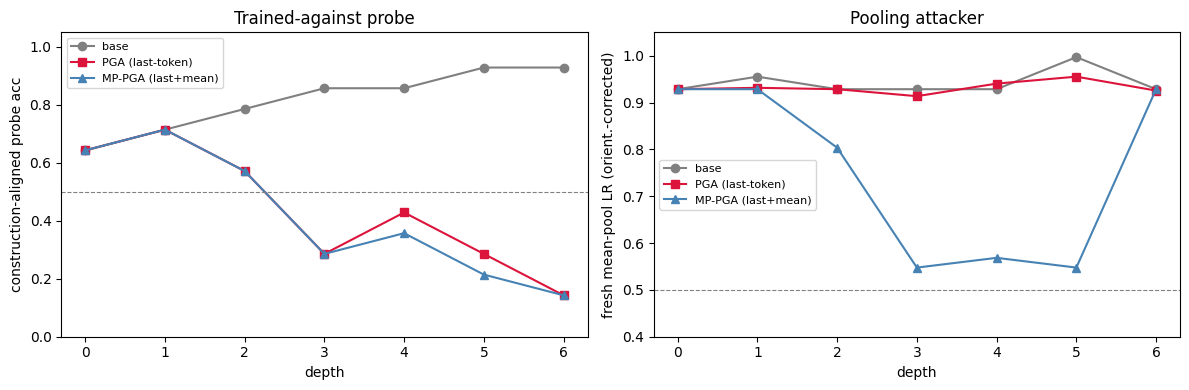

saved fig_mp_pga.{png,pdf}


In [18]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['savefig.dpi'] = 600
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
xs = list(range(N_DEPTHS))
axes[0].plot(xs, base_probe, marker='o', color='gray', label='base')
axes[0].plot(xs, A_probe, marker='s', color='crimson', label='PGA (last-token)')
axes[0].plot(xs, B_probe, marker='^', color='steelblue', label='MP-PGA (last+mean)')
axes[0].axhline(0.5, color='gray', lw=0.8, ls='--')
axes[0].set_xlabel('depth'); axes[0].set_ylabel('construction-aligned probe acc')
axes[0].set_ylim(0, 1.05); axes[0].set_title('Trained-against probe'); axes[0].legend(fontsize=8)
axes[1].plot(xs, base_mp, marker='o', color='gray', label='base')
axes[1].plot(xs, a_mp, marker='s', color='crimson', label='PGA (last-token)')
axes[1].plot(xs, b_mp, marker='^', color='steelblue', label='MP-PGA (last+mean)')
axes[1].axhline(0.5, color='gray', lw=0.8, ls='--')
axes[1].set_xlabel('depth'); axes[1].set_ylabel('fresh mean-pool LR (orient.-corrected)')
axes[1].set_ylim(0.4, 1.05); axes[1].set_title('Pooling attacker'); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUT, 'fig_mp_pga.png'), dpi=600, bbox_inches='tight')
plt.savefig(os.path.join(OUT, 'fig_mp_pga.pdf'), bbox_inches='tight')
plt.show()
print('saved fig_mp_pga.{png,pdf}')


## Reporting notes

If all three criteria pass: report variant B as the constructive answer to the pooling-attack
finding ("the failure mode is position scope; widening the alignment scope closes it"), with
the full fresh-suite table for base/A/B and the saved adapter. If criterion 1 fails: report
the pooling attack as an open limitation of position-scoped alignment; do not soften it. In
either case, variant A's numbers document that this notebook's trainer reproduces the
released method's qualitative behaviour, tying the new results to the paper's.
